README !!!
1. MULTI LOSS FUNCTION - Sentence Transformer -> similarity (0/1) dan MSE (score/label) [bisa juga pake weighted sum of losses]
2. LLM AS DATA GENERATOR - increase data training
3. (?) BERT + MOE


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## BERT

In [37]:
df_bert = pd.read_csv("../experiments/results/results_model_bert.csv")
print(df_bert.info())
df_bert.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      48 non-null     int64  
 1   model_name     48 non-null     object 
 2   batch_size     48 non-null     int64  
 3   epochs         48 non-null     int64  
 4   learning_rate  48 non-null     float64
 5   warm_up        48 non-null     float64
 6   training_time  48 non-null     float64
 7   peak_memory    48 non-null     float64
 8   test_mse       48 non-null     float64
 9   test_mae       48 non-null     float64
 10  test_rmse      48 non-null     float64
 11  test_pearson   48 non-null     float64
 12  use_reference  48 non-null     bool   
dtypes: bool(1), float64(8), int64(3), object(1)
memory usage: 4.7+ KB
None


,config_id,model_name,batch_size,epochs,learning_rate,warm_up,training_time,peak_memory,test_mse,test_mae,test_rmse,test_pearson,use_reference
0,0,indobenchmark/indobert-lite-base-p2,4,26,0.00001,0.0,3100.540767,1352.484863,0.010426,0.077448,0.102279,0.919026,False
1,1,indobenchmark/indobert-lite-base-p2,4,23,0.00002,0.0,2650.152098,1354.086426,0.011282,0.081722,0.106662,0.915975,False
2,2,indobenchmark/indobert-lite-base-p2,4,16,0.00005,0.0,1807.213705,1354.086426,0.012347,0.085333,0.111536,0.903658,False
3,3,indobenchmark/indobert-lite-base-p2,4,19,0.00010,0.0,2137.908230,1354.086426,0.065027,0.209438,0.255902,0.256816,False
4,4,indobenchmark/indobert-lite-base-p2,8,16,0.00001,0.0,1666.842517,2545.281738,0.011705,0.082005,0.108225,0.907612,False


In [15]:
df_bert_epoch = pd.read_csv("../experiments/results/results_epoch_bert.csv")
print(df_bert_epoch.info())
df_bert_epoch.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1078 entries, 0 to 1077
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      1078 non-null   int64  
 1   epoch          1078 non-null   int64  
 2   train_mse      1078 non-null   float64
 3   train_mae      1078 non-null   float64
 4   train_rmse     1078 non-null   float64
 5   train_pearson  1078 non-null   float64
 6   valid_mse      1078 non-null   float64
 7   valid_mae      1078 non-null   float64
 8   valid_rmse     1078 non-null   float64
 9   valid_pearson  1078 non-null   float64
 10  learning_rate  1078 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 92.8 KB
None


,config_id,epoch,train_mse,train_mae,train_rmse,train_pearson,valid_mse,valid_mae,valid_rmse,valid_pearson,learning_rate
0,0,1,0.027491,0.123635,0.165722,0.792133,0.020528,0.106214,0.144242,0.831866,0.00001
1,0,2,0.013620,0.089236,0.116705,0.902948,0.017523,0.096804,0.133288,0.853265,0.00001
2,0,3,0.009178,0.072872,0.095795,0.935686,0.015513,0.092112,0.125300,0.871403,0.00001
3,0,4,0.006063,0.060086,0.077860,0.958007,0.015295,0.091704,0.124379,0.875751,0.00001
4,0,5,0.004868,0.053500,0.069792,0.966404,0.014584,0.090314,0.121336,0.883368,0.00001


### Top 5 Hyperparameter

In [36]:
print("\n============== Top 5 Configurations by MSE (Lower is Better) ==============")
top_mse = df_bert.nsmallest(5, 'test_mse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_mse', 'use_reference']].copy()
print(top_mse.to_string(index=False))

print("\n============== Top 5 Configurations by MAE (Lower is Better) ==============")
top_mae = df_bert.nsmallest(5, 'test_mae')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_mae', 'use_reference']].copy()
print(top_mae.to_string(index=False))

print("\n============== Top 5 Configurations by RMSE (Lower is Better) ==============")
top_rmse = df_bert.nsmallest(5, 'test_rmse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_rmse', 'use_reference']].copy()
print(top_rmse.to_string(index=False))

print("\n============== Top 5 Configurations by Pearson Correlation (Higher is Better) ==============")
top_pearson = df_bert.nlargest(5, 'test_pearson')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_pearson', 'use_reference']].copy()
print(top_pearson.to_string(index=False))


============== Top 5 Configurations by MSE (Lower is Better) ==============
 config_id                          model_name  batch_size  epochs  learning_rate  warm_up  test_mse  use_reference
        33 indobenchmark/indobert-lite-base-p2          16      14        0.00002      0.0  0.006396           True
        25 indobenchmark/indobert-lite-base-p2           4      17        0.00002      0.0  0.006499           True
        39 indobenchmark/indobert-lite-base-p2           4      17        0.00010      0.3  0.006854           True
        29 indobenchmark/indobert-lite-base-p2           8      27        0.00002      0.0  0.006907           True
        47 indobenchmark/indobert-lite-base-p2          16      27        0.00010      0.3  0.006979           True

============== Top 5 Configurations by MAE (Lower is Better) ==============
 config_id                          model_name  batch_size  epochs  learning_rate  warm_up  test_mae  use_reference
        33 indobenchmark/indobert-

In [3]:
def plot_training(df):
    metrics = ['mse', 'mae', 'rmse', 'pearson']
    fig, axes = plt.subplots(2, 2, figsize=(8, 6))

    for ax, title in zip(axes.flat, metrics):
        ax.plot(df['epoch'], df[f'train_{title}'], marker='o', label=f'Train {title.upper()}', linestyle='-')
        ax.plot(df['epoch'], df[f'valid_{title}'], marker='s', label=f'Valid {title.upper()}', linestyle='--')

        ax.set_xlabel('Epochs')
        ax.set_ylabel(f'{title.upper()}')
        ax.set_title(f'Training vs Validation {title.upper()}')
        ax.legend()
        ax.grid()

    plt.tight_layout()
    plt.show()

#### Config 33 Analysis

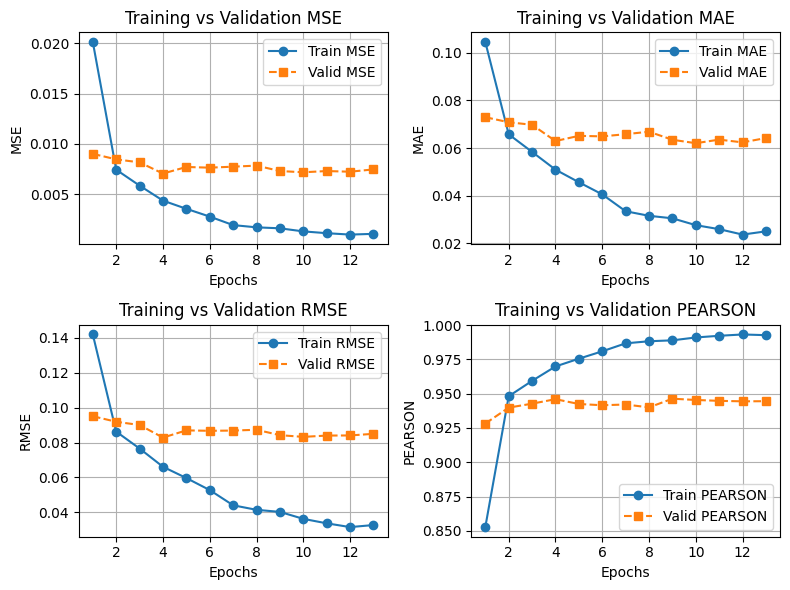

In [69]:
df_bert_33 = df_bert_epoch[df_bert_epoch['config_id']==33]
plot_training(df_bert_33)

#### Config 25 Analysis

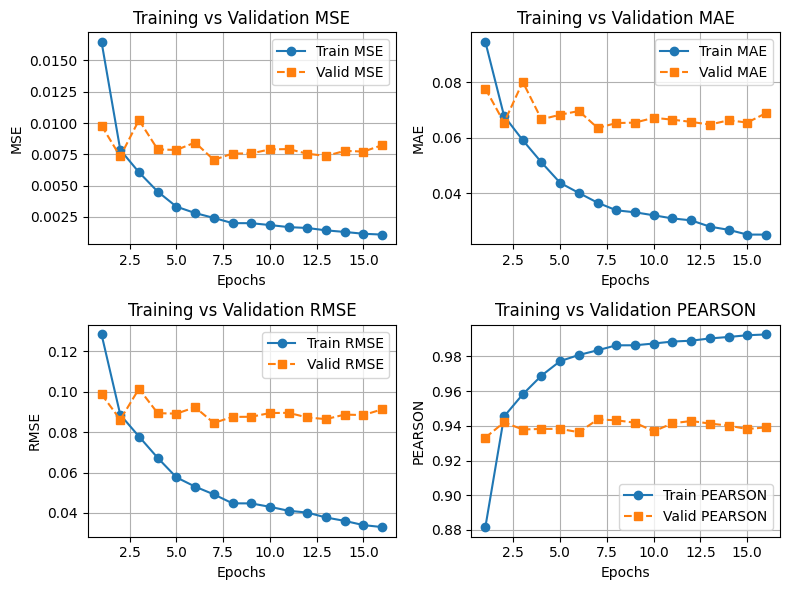

In [70]:
df_bert_25 = df_bert_epoch[df_bert_epoch['config_id']==25]
plot_training(df_bert_25)

#### Analysis based on config 33 & 25

This 2 model suggests overfitting.

- The model learns the training data too well, leading to very low errors.
- However, the validation error remains stagnant instead of decreasing, meaning the model is not improving on unseen data.
- The Pearson correlation confirms that training performance is much better than validation, which is another indicator of overfitting.

How to Address Overfitting?
- Regularization: Try L2 regularization (weight decay) to prevent excessive fitting.
- Dropout: Introduce dropout layers to reduce reliance on specific features.
- Early Stopping: Stop training when validation loss stops improving to prevent overfitting.
- More Data: Increase dataset size or use data augmentation if possible.
- Reduce Model Complexity: Use a simpler architecture to avoid excessive parameterization.

## BERT WITH DIFFERENT DROPOUT

In [62]:
df_bert_after = pd.read_csv("../experiments/results/results_model_bert_after.csv")
print(df_bert_after.info())
df_bert_after.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      4 non-null      int64  
 1   model_name     4 non-null      object 
 2   batch_size     4 non-null      int64  
 3   epochs         4 non-null      int64  
 4   learning_rate  4 non-null      float64
 5   warm_up        4 non-null      int64  
 6   dropout        4 non-null      float64
 7   training_time  4 non-null      float64
 8   peak_memory    4 non-null      float64
 9   test_mse       4 non-null      float64
 10  test_mae       4 non-null      float64
 11  test_rmse      4 non-null      float64
 12  test_pearson   4 non-null      float64
 13  use_reference  4 non-null      bool   
dtypes: bool(1), float64(8), int64(4), object(1)
memory usage: 548.0+ bytes
None


,config_id,model_name,batch_size,epochs,learning_rate,warm_up,dropout,training_time,peak_memory,test_mse,test_mae,test_rmse,test_pearson,use_reference
0,0,indobenchmark/indobert-lite-base-p2,16,37,0.00002,0,0.3,3706.633933,4910.648926,0.006868,0.061979,0.083022,0.946496,True
1,1,indobenchmark/indobert-lite-base-p2,4,25,0.00002,0,0.3,2965.852481,4910.648926,0.007955,0.067636,0.089548,0.938345,True
2,2,indobenchmark/indobert-lite-base-p2,16,24,0.00002,0,0.5,2426.433714,4913.352051,0.006857,0.061268,0.082981,0.946619,True
3,3,indobenchmark/indobert-lite-base-p2,4,49,0.00002,0,0.5,5802.390075,4913.352051,0.007196,0.063965,0.085091,0.945000,True


In [63]:
df_bert_epoch_after = pd.read_csv("../experiments/results/results_epoch_bert_after.csv")
print(df_bert_epoch_after.info())
df_bert_epoch_after.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      131 non-null    int64  
 1   epoch          131 non-null    int64  
 2   train_mse      131 non-null    float64
 3   train_mae      131 non-null    float64
 4   train_rmse     131 non-null    float64
 5   train_pearson  131 non-null    float64
 6   valid_mse      131 non-null    float64
 7   valid_mae      131 non-null    float64
 8   valid_rmse     131 non-null    float64
 9   valid_pearson  131 non-null    float64
 10  learning_rate  131 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 11.4 KB
None


,config_id,epoch,train_mse,train_mae,train_rmse,train_pearson,valid_mse,valid_mae,valid_rmse,valid_pearson,learning_rate
0,0,1,0.114171,0.262452,0.337935,0.474057,0.021084,0.110962,0.145428,0.847919,0.00002
1,0,2,0.060809,0.197970,0.246564,0.668905,0.030098,0.150610,0.174469,0.894435,0.00002
2,0,3,0.047740,0.176509,0.218484,0.735934,0.013620,0.092471,0.117627,0.915428,0.00002
3,0,4,0.040474,0.164584,0.201179,0.764587,0.013326,0.092863,0.116498,0.922141,0.00002
4,0,5,0.032430,0.145070,0.180099,0.806397,0.013086,0.089308,0.113788,0.928013,0.00002


### Top Hyperparameter

In [66]:
print("\n============== Top 4 Configurations by MSE (Lower is Better) ==============")
top_mse = df_bert_after.nsmallest(4, 'test_mse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_mse', 'use_reference']].copy()
print(top_mse.to_string(index=False))

print("\n============== Top 4 Configurations by MAE (Lower is Better) ==============")
top_mae = df_bert_after.nsmallest(4, 'test_mae')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_mae', 'use_reference']].copy()
print(top_mae.to_string(index=False))

print("\n============== Top 4 Configurations by RMSE (Lower is Better) ==============")
top_rmse = df_bert_after.nsmallest(4, 'test_rmse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_rmse', 'use_reference']].copy()
print(top_rmse.to_string(index=False))

print("\n============== Top 4 Configurations by Pearson Correlation (Higher is Better) ==============")
top_pearson = df_bert_after.nlargest(4, 'test_pearson')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_pearson', 'use_reference']].copy()
print(top_pearson.to_string(index=False))


============== Top 4 Configurations by MSE (Lower is Better) ==============
 config_id                          model_name  batch_size  epochs  learning_rate  warm_up  dropout  test_mse  use_reference
         2 indobenchmark/indobert-lite-base-p2          16      24        0.00002        0      0.5  0.006857           True
         0 indobenchmark/indobert-lite-base-p2          16      37        0.00002        0      0.3  0.006868           True
         3 indobenchmark/indobert-lite-base-p2           4      49        0.00002        0      0.5  0.007196           True
         1 indobenchmark/indobert-lite-base-p2           4      25        0.00002        0      0.3  0.007955           True

============== Top 4 Configurations by MAE (Lower is Better) ==============
 config_id                          model_name  batch_size  epochs  learning_rate  warm_up  dropout  test_mae  use_reference
         2 indobenchmark/indobert-lite-base-p2          16      24        0.00002        0      

## Analysis Best Hyperparameter

#### Config 2

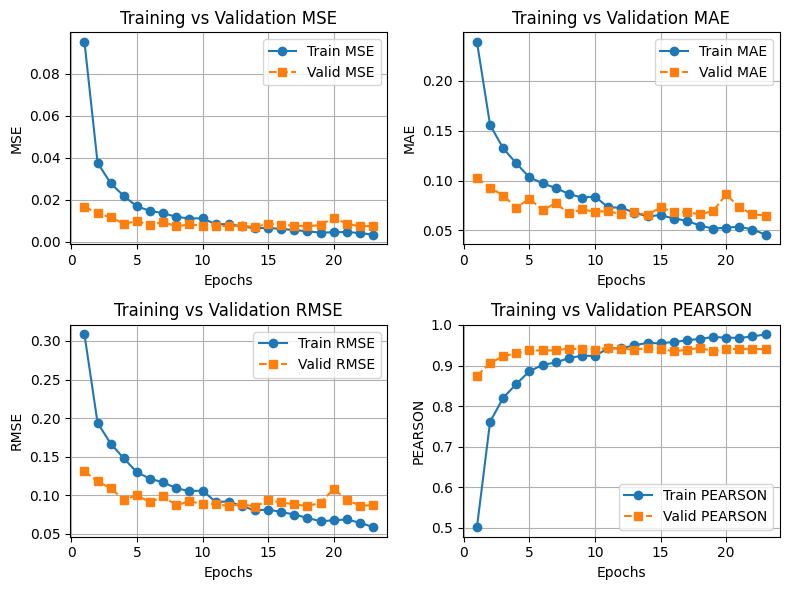

In [73]:
df_bert_after_2 = df_bert_epoch_after[df_bert_epoch_after['config_id']==2]
plot_training(df_bert_after_2)

#### Config 0

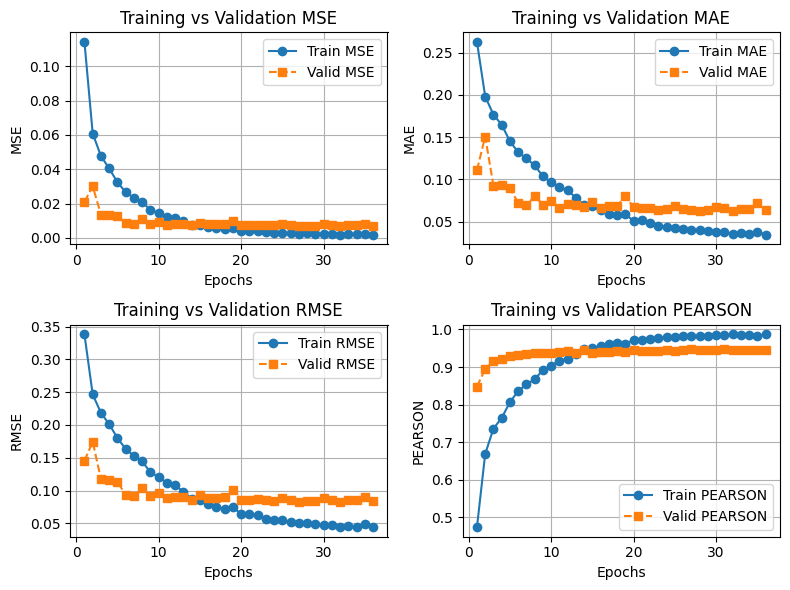

In [74]:
df_bert_after_0 = df_bert_epoch_after[df_bert_epoch_after['config_id']==0]
plot_training(df_bert_after_0)

## BERT WITH FREEZE THE TRANSFORMER LAYER

In [3]:
df_bert_freeze = pd.read_csv("../experiments/results/results_model_bert_freeze.csv")
print(df_bert_freeze.info())
df_bert_freeze.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      12 non-null     int64  
 1   model_name     12 non-null     object 
 2   batch_size     12 non-null     int64  
 3   epochs         12 non-null     int64  
 4   learning_rate  12 non-null     float64
 5   warm_up        12 non-null     float64
 6   dropout        12 non-null     float64
 7   training_time  12 non-null     float64
 8   peak_memory    12 non-null     float64
 9   test_mse       12 non-null     float64
 10  test_mae       12 non-null     float64
 11  test_rmse      12 non-null     float64
 12  test_pearson   12 non-null     float64
 13  use_reference  12 non-null     bool   
dtypes: bool(1), float64(9), int64(3), object(1)
memory usage: 1.4+ KB
None


,config_id,model_name,batch_size,epochs,learning_rate,warm_up,dropout,training_time,peak_memory,test_mse,test_mae,test_rmse,test_pearson,use_reference
0,0,indobenchmark/indobert-lite-base-p2,16,156,0.00002,0.0,0.3,5764.752388,411.579102,0.014257,0.095280,0.119661,0.887377,True
1,1,indobenchmark/indobert-lite-base-p2,4,91,0.00002,0.0,0.3,3838.210329,411.579102,0.013837,0.094283,0.118121,0.888934,True
2,2,indobenchmark/indobert-lite-base-p2,16,123,0.00002,0.0,0.5,5160.705721,411.579102,0.016987,0.106236,0.130478,0.865610,True
3,3,indobenchmark/indobert-lite-base-p2,4,72,0.00002,0.0,0.5,3030.650865,411.579102,0.015511,0.100333,0.125059,0.877218,True
4,4,indobenchmark/indobert-lite-base-p2,16,17,0.00100,0.0,0.3,631.965166,411.579102,0.014371,0.094332,0.120113,0.887919,True


In [4]:
df_bert_epoch_freeze = pd.read_csv("../experiments/results/results_epoch_bert_freeze.csv")
print(df_bert_epoch_freeze.info())
df_bert_epoch_freeze.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      598 non-null    int64  
 1   epoch          598 non-null    int64  
 2   train_mse      598 non-null    float64
 3   train_mae      598 non-null    float64
 4   train_rmse     598 non-null    float64
 5   train_pearson  598 non-null    float64
 6   valid_mse      598 non-null    float64
 7   valid_mae      598 non-null    float64
 8   valid_rmse     598 non-null    float64
 9   valid_pearson  598 non-null    float64
 10  learning_rate  598 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 51.5 KB
None


,config_id,epoch,train_mse,train_mae,train_rmse,train_pearson,valid_mse,valid_mae,valid_rmse,valid_pearson,learning_rate
0,0,1,0.425296,0.511494,0.652228,-0.219253,0.174034,0.319946,0.424754,-0.320469,0.00002
1,0,2,0.247657,0.397352,0.497704,-0.092314,0.136449,0.293363,0.375785,-0.168578,0.00002
2,0,3,0.218632,0.367861,0.467560,-0.008066,0.109636,0.263668,0.336404,0.007579,0.00002
3,0,4,0.195941,0.352233,0.442619,0.108425,0.091242,0.242647,0.306441,0.166445,0.00002
4,0,5,0.170286,0.327632,0.412629,0.182595,0.078507,0.226627,0.283876,0.291660,0.00002


### Top 5 Hyperparameter

In [5]:
print("\n============== Top 5 Configurations by MSE (Lower is Better) ==============")
top_mse = df_bert_freeze.nsmallest(5, 'test_mse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_mse', 'use_reference']].copy()
print(top_mse.to_string(index=False))

print("\n============== Top 5 Configurations by MAE (Lower is Better) ==============")
top_mae = df_bert_freeze.nsmallest(5, 'test_mae')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_mae', 'use_reference']].copy()
print(top_mae.to_string(index=False))

print("\n============== Top 5 Configurations by RMSE (Lower is Better) ==============")
top_rmse = df_bert_freeze.nsmallest(5, 'test_rmse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_rmse', 'use_reference']].copy()
print(top_rmse.to_string(index=False))

print("\n============== Top 5 Configurations by Pearson Correlation (Higher is Better) ==============")
top_pearson = df_bert_freeze.nlargest(5, 'test_pearson')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_pearson', 'use_reference']].copy()
print(top_pearson.to_string(index=False))


============== Top 5 Configurations by MSE (Lower is Better) ==============
 config_id                          model_name  batch_size  epochs  learning_rate  warm_up  test_mse  use_reference
         1 indobenchmark/indobert-lite-base-p2           4      91        0.00002      0.0  0.013837           True
         0 indobenchmark/indobert-lite-base-p2          16     156        0.00002      0.0  0.014257           True
         4 indobenchmark/indobert-lite-base-p2          16      17        0.00100      0.0  0.014371           True
         3 indobenchmark/indobert-lite-base-p2           4      72        0.00002      0.0  0.015511           True
         8 indobenchmark/indobert-lite-base-p2          16      22        0.00100      0.0  0.016466           True

============== Top 5 Configurations by MAE (Lower is Better) ==============
 config_id                          model_name  batch_size  epochs  learning_rate  warm_up  test_mae  use_reference
         1 indobenchmark/indobert-

### Analysis Best Hyperparameter

#### Config 1 Analysis

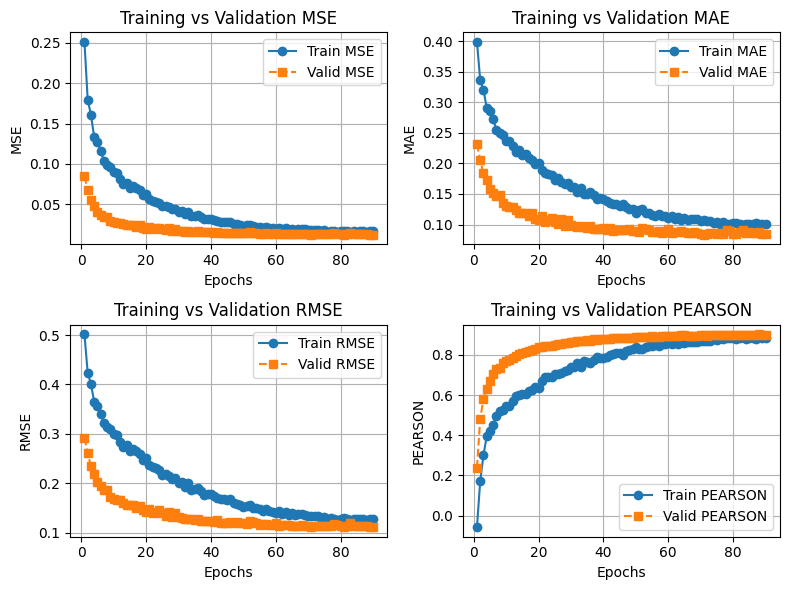

In [7]:
df_bert_freeze_1 = df_bert_epoch_freeze[df_bert_epoch_freeze['config_id']==1]
plot_training(df_bert_freeze_1)

#### Config 4 Analysis

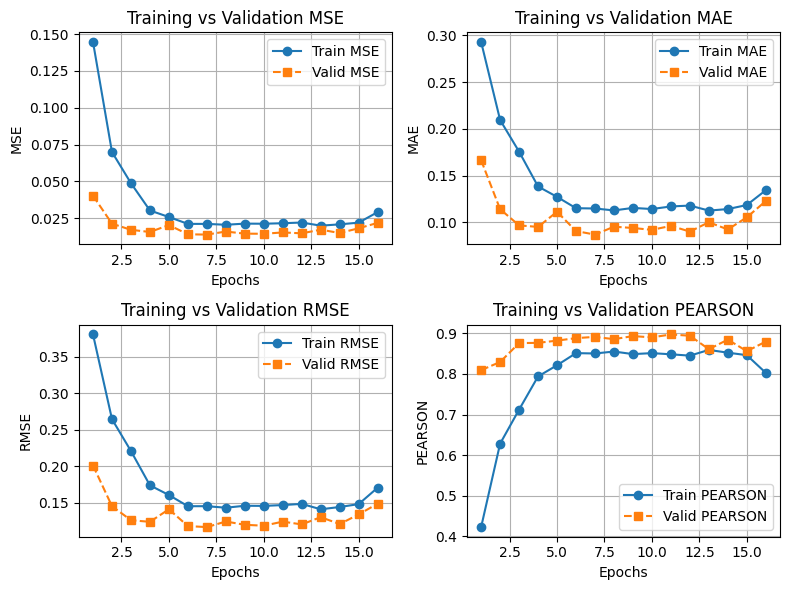

In [8]:
df_bert_freeze_4 = df_bert_epoch_freeze[df_bert_epoch_freeze['config_id']==4]
plot_training(df_bert_freeze_4)

#### Config 0 Analysis

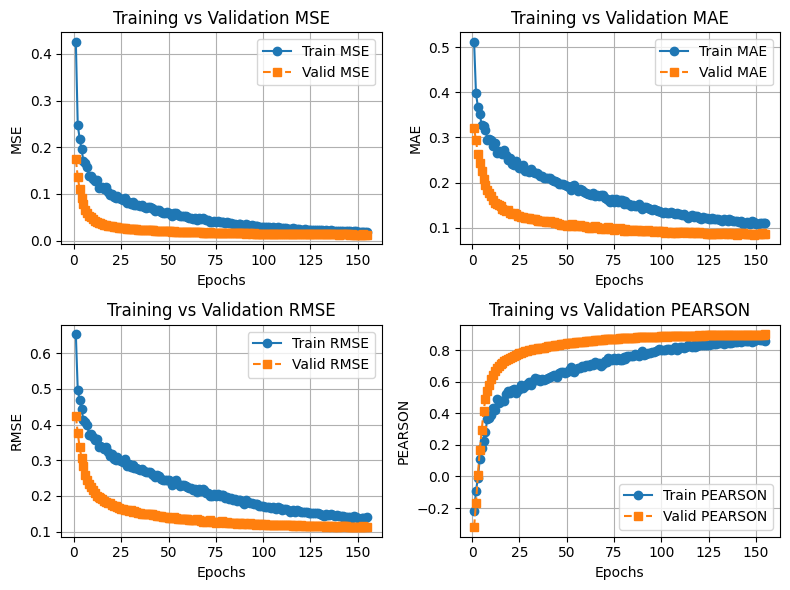

In [9]:
df_bert_freeze_0 = df_bert_epoch_freeze[df_bert_epoch_freeze['config_id']==0]
plot_training(df_bert_freeze_0)

## BERT WITH FREEZE THE TRANSFORMER LAYER, HIGHER LR

In [15]:
df_bert_freeze1 = pd.read_csv("../experiments/results/results_model_bert_freeze1.csv")
print(df_bert_freeze1.info())
df_bert_freeze1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      36 non-null     int64  
 1   model_name     36 non-null     object 
 2   batch_size     36 non-null     int64  
 3   epochs         36 non-null     int64  
 4   learning_rate  36 non-null     float64
 5   warm_up        36 non-null     float64
 6   dropout        36 non-null     float64
 7   training_time  36 non-null     float64
 8   peak_memory    36 non-null     float64
 9   test_mse       36 non-null     float64
 10  test_mae       36 non-null     float64
 11  test_rmse      36 non-null     float64
 12  test_pearson   36 non-null     float64
 13  use_reference  36 non-null     bool   
dtypes: bool(1), float64(9), int64(3), object(1)
memory usage: 3.8+ KB
None


,config_id,model_name,batch_size,epochs,learning_rate,warm_up,dropout,training_time,peak_memory,test_mse,test_mae,test_rmse,test_pearson,use_reference
0,0,indobenchmark/indobert-lite-base-p2,4,44,0.0005,0.0,0.0,2185.788796,216.899414,0.012129,0.086601,0.110571,0.905590,True
1,1,indobenchmark/indobert-lite-base-p2,4,36,0.0010,0.0,0.0,1925.012712,216.899414,0.019624,0.113222,0.140331,0.867307,True
2,2,indobenchmark/indobert-lite-base-p2,4,36,0.0020,0.0,0.0,1927.365717,217.399414,0.020094,0.114702,0.142345,0.847282,True
3,3,indobenchmark/indobert-lite-base-p2,4,43,0.0050,0.0,0.0,2325.361950,217.399414,0.039316,0.156453,0.198919,0.787024,True
4,4,indobenchmark/indobert-lite-base-p2,8,49,0.0005,0.0,0.0,1889.234716,283.891602,0.014350,0.093145,0.119786,0.891945,True


In [16]:
df_bert_epoch_freeze1 = pd.read_csv("../experiments/results/results_epoch_bert_freeze1.csv")
print(df_bert_epoch_freeze1.info())
df_bert_epoch_freeze1.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1431 entries, 0 to 1430
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      1431 non-null   int64  
 1   epoch          1431 non-null   int64  
 2   train_mse      1431 non-null   float64
 3   train_mae      1431 non-null   float64
 4   train_rmse     1431 non-null   float64
 5   train_pearson  1431 non-null   float64
 6   valid_mse      1431 non-null   float64
 7   valid_mae      1431 non-null   float64
 8   valid_rmse     1431 non-null   float64
 9   valid_pearson  1431 non-null   float64
 10  learning_rate  1431 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 123.1 KB
None


,config_id,epoch,train_mse,train_mae,train_rmse,train_pearson,valid_mse,valid_mae,valid_rmse,valid_pearson,learning_rate
0,0,1,0.050565,0.164560,0.224853,0.663766,0.022823,0.115978,0.152111,0.819143,0.0005
1,0,2,0.022774,0.118629,0.150940,0.842446,0.018629,0.104258,0.137446,0.861168,0.0005
2,0,3,0.019432,0.110212,0.139426,0.866279,0.052780,0.203176,0.231011,0.855315,0.0005
3,0,4,0.018317,0.106579,0.135369,0.873886,0.017344,0.102659,0.132068,0.857317,0.0005
4,0,5,0.016515,0.100992,0.128514,0.885488,0.019377,0.107358,0.139470,0.884597,0.0005


### Top 5 Hyperparameter

In [20]:
print("\n============== Top 5 Configurations by MSE (Lower is Better) ==============")
top_mse = df_bert_freeze1.nsmallest(5, 'test_mse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_mse', 'use_reference']].copy()
print(top_mse.to_string(index=False))

print("\n============== Top 5 Configurations by MAE (Lower is Better) ==============")
top_mae = df_bert_freeze1.nsmallest(5, 'test_mae')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_mae', 'use_reference']].copy()
print(top_mae.to_string(index=False))

print("\n============== Top 5 Configurations by RMSE (Lower is Better) ==============")
top_rmse = df_bert_freeze1.nsmallest(5, 'test_rmse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_rmse', 'use_reference']].copy()
print(top_rmse.to_string(index=False))

print("\n============== Top 5 Configurations by Pearson Correlation (Higher is Better) ==============")
top_pearson = df_bert_freeze1.nlargest(5, 'test_pearson')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_pearson', 'use_reference']].copy()
print(top_pearson.to_string(index=False))


============== Top 5 Configurations by MSE (Lower is Better) ==============
 config_id                          model_name  batch_size  epochs  learning_rate  warm_up  dropout  test_mse  use_reference
         0 indobenchmark/indobert-lite-base-p2           4      44         0.0005      0.0      0.0  0.012129           True
         9 indobenchmark/indobert-lite-base-p2          16      70         0.0010      0.0      0.0  0.012164           True
         8 indobenchmark/indobert-lite-base-p2          16      72         0.0005      0.0      0.0  0.012339           True
         5 indobenchmark/indobert-lite-base-p2           8      41         0.0010      0.0      0.0  0.013497           True
        20 indobenchmark/indobert-lite-base-p2          16      30         0.0005      0.0      0.3  0.014279           True

============== Top 5 Configurations by MAE (Lower is Better) ==============
 config_id                          model_name  batch_size  epochs  learning_rate  warm_up  drop

### Analysis Best Hyperparameter

#### Config 9 Analysis

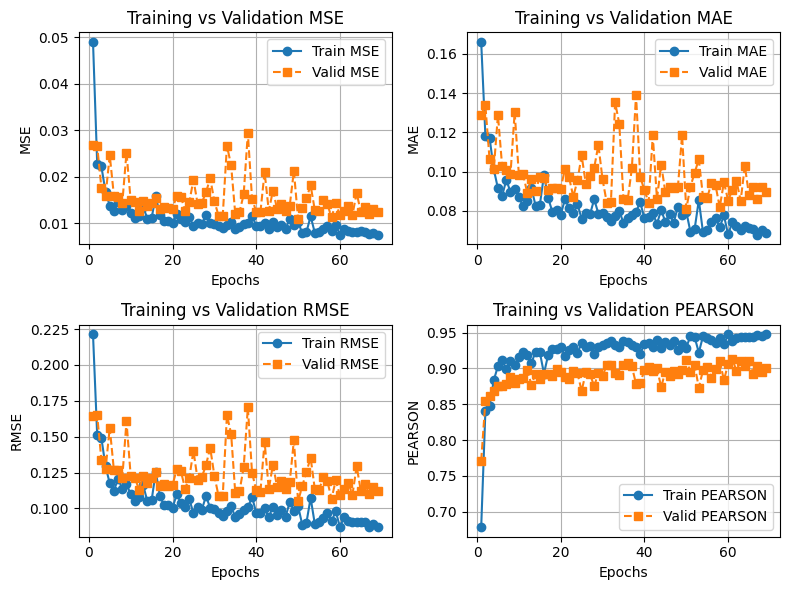

In [18]:
df_bert_freeze1_9 = df_bert_epoch_freeze1[df_bert_epoch_freeze1['config_id']==9]
plot_training(df_bert_freeze1_9)

#### Config 0 Analysis

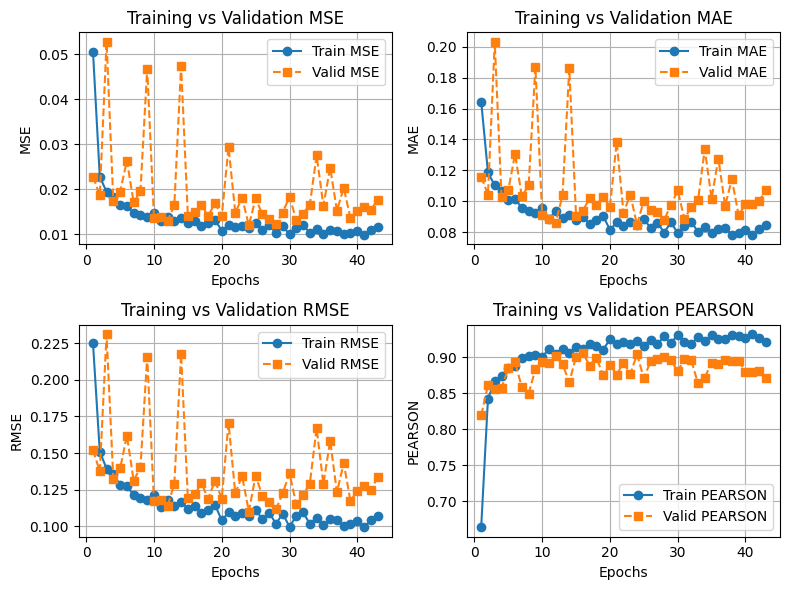

In [19]:
df_bert_freeze1_0 = df_bert_epoch_freeze1[df_bert_epoch_freeze1['config_id']==0]
plot_training(df_bert_freeze1_0)

## Sentence-BERT

In [38]:
df_sbert = pd.read_csv("../experiments/results/results_model_sbert.csv")
print(df_sbert.info())
df_sbert.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      24 non-null     int64  
 1   model_name     24 non-null     object 
 2   batch_size     24 non-null     int64  
 3   epochs         24 non-null     int64  
 4   learning_rate  24 non-null     float64
 5   warm_up        24 non-null     float64
 6   training_time  24 non-null     float64
 7   peak_memory    24 non-null     float64
 8   test_mse       24 non-null     float64
 9   test_mae       24 non-null     float64
 10  test_rmse      24 non-null     float64
 11  test_pearson   24 non-null     float64
dtypes: float64(8), int64(3), object(1)
memory usage: 2.4+ KB
None


,config_id,model_name,batch_size,epochs,learning_rate,warm_up,training_time,peak_memory,test_mse,test_mae,test_rmse,test_pearson
0,0,sentence-transformers/paraphrase-multilingual-...,4,38,0.00001,0.0,4142.623503,6429.441406,0.010930,0.076444,0.104915,0.913531
1,1,sentence-transformers/paraphrase-multilingual-...,4,60,0.00001,0.3,6486.738063,6429.441406,0.011149,0.078957,0.105930,0.911879
2,2,sentence-transformers/paraphrase-multilingual-...,4,36,0.00002,0.0,4033.998030,6429.441406,0.010249,0.075680,0.101490,0.919654
3,3,sentence-transformers/paraphrase-multilingual-...,4,36,0.00002,0.3,4107.954933,6429.441406,0.011019,0.080337,0.105223,0.913281
4,4,sentence-transformers/paraphrase-multilingual-...,4,32,0.00005,0.0,3525.914109,6429.441406,0.012640,0.081824,0.112794,0.900399


In [39]:
df_sbert_epoch = pd.read_csv("../experiments/results/results_epoch_sbert.csv")
print(df_sbert_epoch.info())
df_sbert_epoch.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      911 non-null    int64  
 1   epoch          911 non-null    int64  
 2   train_mse      911 non-null    float64
 3   train_mae      911 non-null    float64
 4   train_rmse     911 non-null    float64
 5   train_pearson  911 non-null    float64
 6   valid_mse      911 non-null    float64
 7   valid_mae      911 non-null    float64
 8   valid_rmse     911 non-null    float64
 9   valid_pearson  910 non-null    float64
 10  learning_rate  911 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 78.4 KB
None


,config_id,epoch,train_mse,train_mae,train_rmse,train_pearson,valid_mse,valid_mae,valid_rmse,valid_pearson,learning_rate
0,0,1,0.029420,0.130336,0.171479,0.778005,0.024174,0.112385,0.156110,0.815898,0.00001
1,0,2,0.012347,0.084394,0.111122,0.913476,0.018917,0.100013,0.138307,0.866943,0.00001
2,0,3,0.007584,0.066369,0.087095,0.947765,0.016009,0.089852,0.127292,0.874508,0.00001
3,0,4,0.005155,0.055409,0.071800,0.964781,0.013480,0.081335,0.116918,0.892534,0.00001
4,0,5,0.003963,0.048907,0.062962,0.973063,0.015977,0.088266,0.127099,0.878665,0.00001


### Top 5 Hyperparameter

In [41]:
print("\n============== Top 5 Configurations by MSE (Lower is Better) ==============")
top_mse = df_sbert.nsmallest(5, 'test_mse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_mse']].copy()
print(top_mse.to_string(index=False))

print("\n============== Top 5 Configurations by MAE (Lower is Better) ==============")
top_mae = df_sbert.nsmallest(5, 'test_mae')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_mae']].copy()
print(top_mae.to_string(index=False))

print("\n============== Top 5 Configurations by RMSE (Lower is Better) ==============")
top_rmse = df_sbert.nsmallest(5, 'test_rmse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_rmse']].copy()
print(top_rmse.to_string(index=False))

print("\n============== Top 5 Configurations by Pearson Correlation (Higher is Better) ==============")
top_pearson = df_sbert.nlargest(5, 'test_pearson')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_pearson']].copy()
print(top_pearson.to_string(index=False))


============== Top 5 Configurations by MSE (Lower is Better) ==============
 config_id                                                  model_name  batch_size  epochs  learning_rate  warm_up  test_mse
         2 sentence-transformers/paraphrase-multilingual-mpnet-base-v2           4      36        0.00002      0.0  0.010249
        10 sentence-transformers/paraphrase-multilingual-mpnet-base-v2           8      30        0.00002      0.0  0.010395
        20 sentence-transformers/paraphrase-multilingual-mpnet-base-v2          16      30        0.00005      0.0  0.010720
         0 sentence-transformers/paraphrase-multilingual-mpnet-base-v2           4      38        0.00001      0.0  0.010930
        23 sentence-transformers/paraphrase-multilingual-mpnet-base-v2          16      41        0.00010      0.3  0.010991

============== Top 5 Configurations by MAE (Lower is Better) ==============
 config_id                                                  model_name  batch_size  epochs  lear

## Analysis Best Hyperparameter

#### Config 2 Analysis

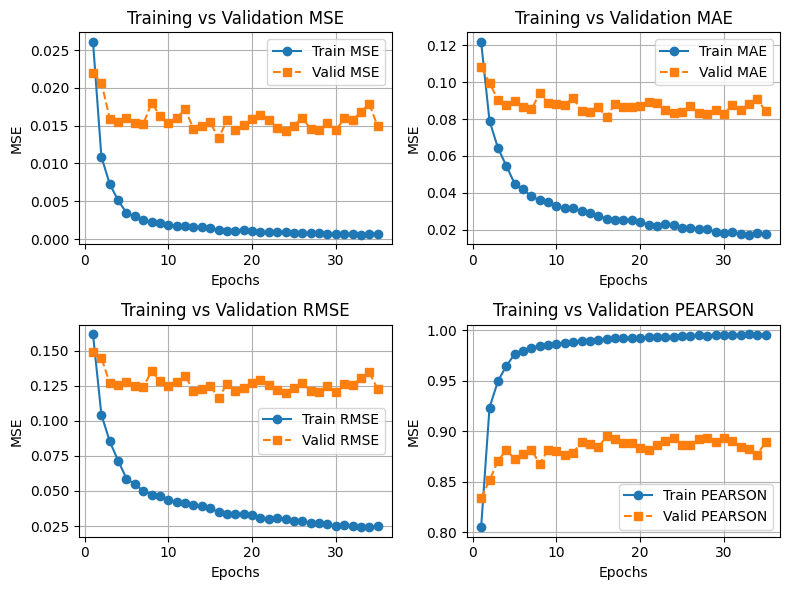

In [44]:
df_sbert_2 = df_sbert_epoch[df_sbert_epoch['config_id']==2]
plot_training(df_sbert_2)

#### Config 10 Analysis

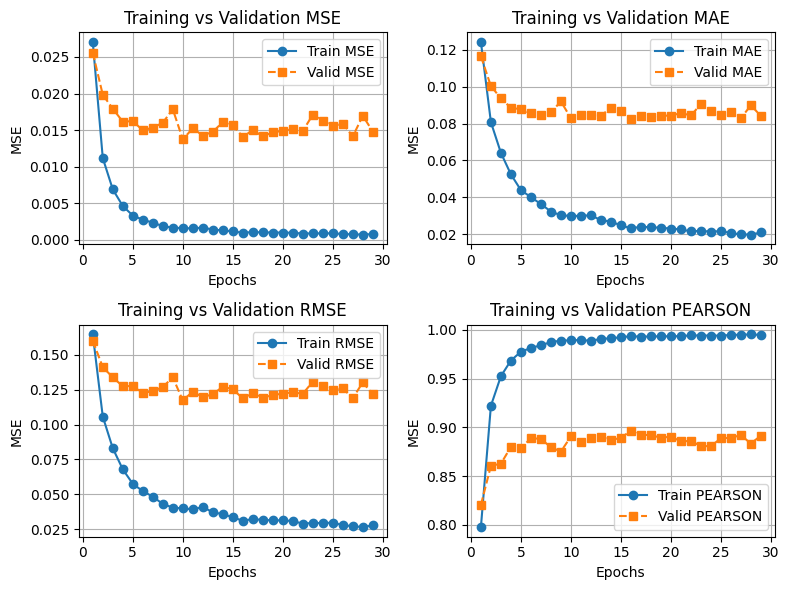

In [46]:
df_sbert_10 = df_sbert_epoch[df_sbert_epoch['config_id']==10]
plot_training(df_sbert_10)

## SBERT WITH DIFFERENT DROPOUT

In [75]:
df_sbert_after = pd.read_csv("../experiments/results/results_model_sbert_after.csv")
print(df_sbert_after.info())
df_sbert_after.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      4 non-null      int64  
 1   model_name     4 non-null      object 
 2   batch_size     4 non-null      int64  
 3   epochs         4 non-null      int64  
 4   learning_rate  4 non-null      float64
 5   warm_up        4 non-null      float64
 6   dropout        4 non-null      float64
 7   training_time  4 non-null      float64
 8   peak_memory    4 non-null      float64
 9   test_mse       4 non-null      float64
 10  test_mae       4 non-null      float64
 11  test_rmse      4 non-null      float64
 12  test_pearson   4 non-null      float64
dtypes: float64(9), int64(3), object(1)
memory usage: 544.0+ bytes
None


,config_id,model_name,batch_size,epochs,learning_rate,warm_up,dropout,training_time,peak_memory,test_mse,test_mae,test_rmse,test_pearson
0,0,sentence-transformers/paraphrase-multilingual-...,4,16,0.00002,0.0,0.3,1774.599138,6415.501953,0.010976,0.080296,0.105054,0.914012
1,1,sentence-transformers/paraphrase-multilingual-...,4,23,0.00002,0.0,0.5,2528.414586,6416.966797,0.009884,0.075497,0.099825,0.921961
2,2,sentence-transformers/paraphrase-multilingual-...,8,28,0.00002,0.0,0.3,2258.933005,6607.459473,0.010362,0.075489,0.102006,0.918879
3,3,sentence-transformers/paraphrase-multilingual-...,8,14,0.00002,0.0,0.5,1125.663204,6617.959473,0.010747,0.080759,0.103780,0.920549


In [76]:
df_sbert_epoch_after = pd.read_csv("../experiments/results/results_epoch_sbert_after.csv")
print(df_sbert_epoch_after.info())
df_sbert_epoch_after.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      77 non-null     int64  
 1   epoch          77 non-null     int64  
 2   train_mse      77 non-null     float64
 3   train_mae      77 non-null     float64
 4   train_rmse     77 non-null     float64
 5   train_pearson  77 non-null     float64
 6   valid_mse      77 non-null     float64
 7   valid_mae      77 non-null     float64
 8   valid_rmse     77 non-null     float64
 9   valid_pearson  77 non-null     float64
 10  learning_rate  77 non-null     float64
dtypes: float64(9), int64(2)
memory usage: 6.7 KB
None


,config_id,epoch,train_mse,train_mae,train_rmse,train_pearson,valid_mse,valid_mae,valid_rmse,valid_pearson,learning_rate
0,0,1,0.029683,0.126894,0.172214,0.777731,0.020767,0.105846,0.144620,0.837909,0.00002
1,0,2,0.012962,0.086118,0.113851,0.908137,0.018034,0.095663,0.135226,0.863997,0.00002
2,0,3,0.008052,0.068831,0.089747,0.943871,0.023942,0.115522,0.155445,0.868042,0.00002
3,0,4,0.006005,0.059378,0.077515,0.958415,0.015756,0.085585,0.126396,0.878665,0.00002
4,0,5,0.004743,0.052887,0.068862,0.967329,0.017360,0.094106,0.132673,0.875810,0.00002


### Top 5 Hyperparameter

In [78]:
print("\n============== Top 4 Configurations by MSE (Lower is Better) ==============")
top_mse = df_sbert_after.nsmallest(4, 'test_mse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_mse']].copy()
print(top_mse.to_string(index=False))

print("\n============== Top 4 Configurations by MAE (Lower is Better) ==============")
top_mae = df_sbert_after.nsmallest(4, 'test_mae')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_mae']].copy()
print(top_mae.to_string(index=False))

print("\n============== Top 4 Configurations by RMSE (Lower is Better) ==============")
top_rmse = df_sbert_after.nsmallest(4, 'test_rmse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_rmse']].copy()
print(top_rmse.to_string(index=False))

print("\n============== Top 4 Configurations by Pearson Correlation (Higher is Better) ==============")
top_pearson = df_sbert_after.nlargest(5, 'test_pearson')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_pearson']].copy()
print(top_pearson.to_string(index=False))


============== Top 4 Configurations by MSE (Lower is Better) ==============
 config_id                                                  model_name  batch_size  epochs  learning_rate  warm_up  dropout  test_mse
         1 sentence-transformers/paraphrase-multilingual-mpnet-base-v2           4      23        0.00002      0.0      0.5  0.009884
         2 sentence-transformers/paraphrase-multilingual-mpnet-base-v2           8      28        0.00002      0.0      0.3  0.010362
         3 sentence-transformers/paraphrase-multilingual-mpnet-base-v2           8      14        0.00002      0.0      0.5  0.010747
         0 sentence-transformers/paraphrase-multilingual-mpnet-base-v2           4      16        0.00002      0.0      0.3  0.010976

============== Top 4 Configurations by MAE (Lower is Better) ==============
 config_id                                                  model_name  batch_size  epochs  learning_rate  warm_up  dropout  test_mae
         2 sentence-transformers/paraphras

### Analysis Best Hyperparameter

#### Config 1 Analysis

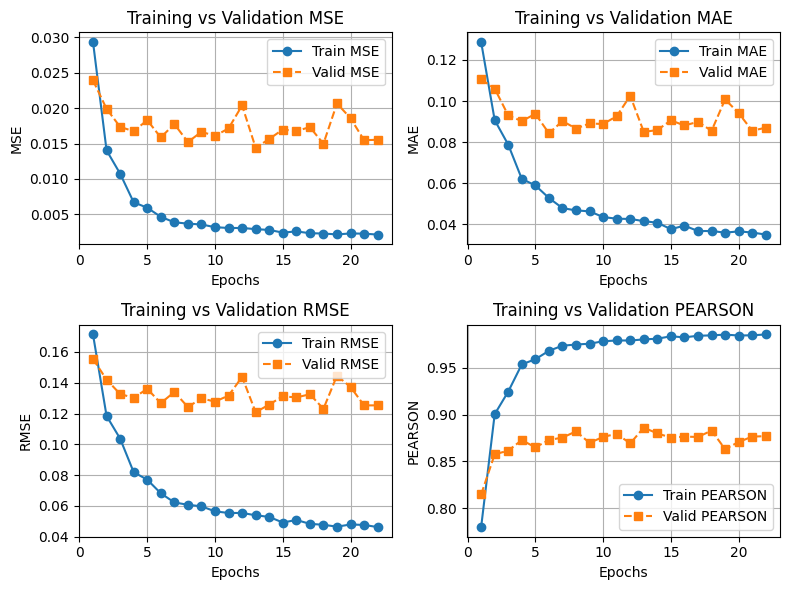

In [79]:
df_sbert_after_1 = df_sbert_epoch_after[df_sbert_epoch_after['config_id']==1]
plot_training(df_sbert_after_1)

#### Config 2 Analysis

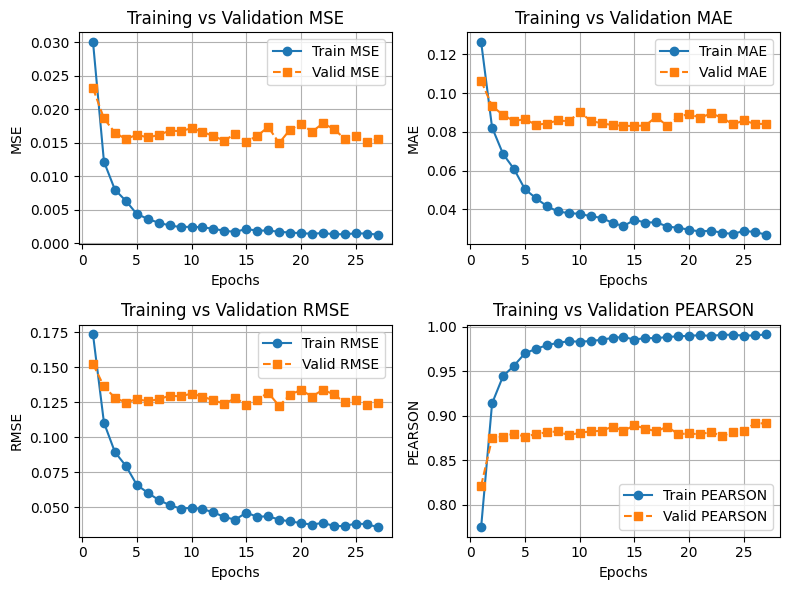

In [80]:
df_sbert_after_2 = df_sbert_epoch_after[df_sbert_epoch_after['config_id']==2]
plot_training(df_sbert_after_2)

## Sentence-IndoBERT

In [10]:
df_sindobert = pd.read_csv("../experiments/results/results_sindobert.csv")
print(df_sindobert.info())
df_sindobert.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      24 non-null     int64  
 1   model_name     24 non-null     object 
 2   batch_size     24 non-null     int64  
 3   epochs         24 non-null     int64  
 4   learning_rate  24 non-null     float64
 5   warm_up        24 non-null     float64
 6   dropout        24 non-null     float64
 7   training_time  24 non-null     float64
 8   peak_memory    24 non-null     float64
 9   test_mse       24 non-null     float64
 10  test_mae       24 non-null     float64
 11  test_rmse      24 non-null     float64
 12  test_pearson   24 non-null     float64
dtypes: float64(9), int64(3), object(1)
memory usage: 2.6+ KB
None


,config_id,model_name,batch_size,epochs,learning_rate,warm_up,dropout,training_time,peak_memory,test_mse,test_mae,test_rmse,test_pearson
0,0,indobenchmark/indobert-lite-base-p2,4,62,0.00001,0.0,0.1,4109.895740,1767.721191,0.010755,0.079205,0.103978,0.915371
1,1,indobenchmark/indobert-lite-base-p2,4,85,0.00001,0.3,0.1,5676.440872,1767.721191,0.011825,0.082442,0.109137,0.905946
2,2,indobenchmark/indobert-lite-base-p2,4,49,0.00002,0.0,0.1,3010.462638,1767.721191,0.010995,0.080275,0.105237,0.914267
3,3,indobenchmark/indobert-lite-base-p2,4,46,0.00002,0.3,0.1,2834.346292,1767.721191,0.011334,0.081701,0.106441,0.910648
4,4,indobenchmark/indobert-lite-base-p2,4,41,0.00005,0.0,0.1,2519.313970,1767.721191,0.010325,0.077047,0.101998,0.922391


In [11]:
df_sindobert_epoch = pd.read_csv("../experiments/results/results_epoch_sindobert.csv")
print(df_sindobert_epoch.info())
df_sindobert_epoch.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1347 entries, 0 to 1346
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      1347 non-null   int64  
 1   epoch          1347 non-null   int64  
 2   train_mse      1347 non-null   float64
 3   train_mae      1347 non-null   float64
 4   train_rmse     1347 non-null   float64
 5   train_pearson  1347 non-null   float64
 6   valid_mse      1347 non-null   float64
 7   valid_mae      1347 non-null   float64
 8   valid_rmse     1347 non-null   float64
 9   valid_pearson  1347 non-null   float64
 10  learning_rate  1347 non-null   float64
dtypes: float64(9), int64(2)
memory usage: 115.9 KB
None


,config_id,epoch,train_mse,train_mae,train_rmse,train_pearson,valid_mse,valid_mae,valid_rmse,valid_pearson,learning_rate
0,0,1,0.055888,0.174686,0.236394,0.641387,0.032858,0.133578,0.182001,0.783943,0.00001
1,0,2,0.027258,0.128946,0.165124,0.813439,0.021422,0.110165,0.146176,0.831440,0.00001
2,0,3,0.020927,0.111995,0.144611,0.856964,0.023517,0.113866,0.153142,0.831238,0.00001
3,0,4,0.016547,0.099424,0.128641,0.886990,0.017862,0.102588,0.134174,0.850880,0.00001
4,0,5,0.013829,0.091219,0.117624,0.905302,0.018752,0.104315,0.136238,0.852464,0.00001


### Top 5 Hyperparameter

In [12]:
print("\n============== Top 5 Configurations by MSE (Lower is Better) ==============")
top_mse = df_sindobert.nsmallest(5, 'test_mse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_mse']].copy()
print(top_mse.to_string(index=False))

print("\n============== Top 5 Configurations by MAE (Lower is Better) ==============")
top_mae = df_sindobert.nsmallest(5, 'test_mae')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_mae']].copy()
print(top_mae.to_string(index=False))

print("\n============== Top 5 Configurations by RMSE (Lower is Better) ==============")
top_rmse = df_sindobert.nsmallest(5, 'test_rmse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_rmse']].copy()
print(top_rmse.to_string(index=False))

print("\n============== Top 5 Configurations by Pearson Correlation (Higher is Better) ==============")
top_pearson = df_sindobert.nlargest(5, 'test_pearson')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_pearson']].copy()
print(top_pearson.to_string(index=False))


============== Top 5 Configurations by MSE (Lower is Better) ==============
 config_id                          model_name  batch_size  epochs  learning_rate  warm_up  test_mse
         4 indobenchmark/indobert-lite-base-p2           4      41        0.00005      0.0  0.010325
         9 indobenchmark/indobert-lite-base-p2           8      59        0.00001      0.3  0.010737
         0 indobenchmark/indobert-lite-base-p2           4      62        0.00001      0.0  0.010755
        22 indobenchmark/indobert-lite-base-p2          16      69        0.00010      0.0  0.010773
        21 indobenchmark/indobert-lite-base-p2          16      69        0.00005      0.3  0.010859

============== Top 5 Configurations by MAE (Lower is Better) ==============
 config_id                          model_name  batch_size  epochs  learning_rate  warm_up  test_mae
         4 indobenchmark/indobert-lite-base-p2           4      41        0.00005      0.0  0.077047
        14 indobenchmark/indobert-lite

## Analysis Best Hyperparameter

#### Config 4 Analysis

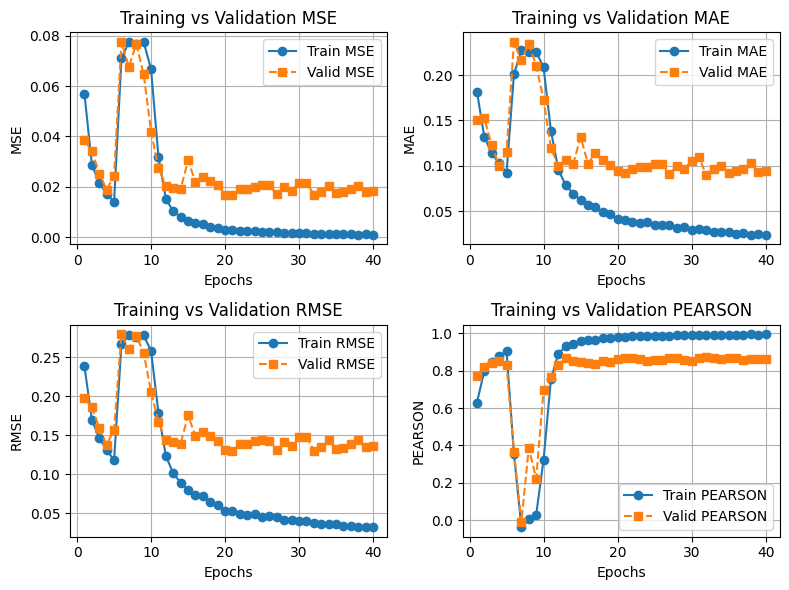

In [13]:
df_sindobert_4 = df_sindobert_epoch[df_sindobert_epoch['config_id']==4]
plot_training(df_sindobert_4)

#### Config 22 Analysis

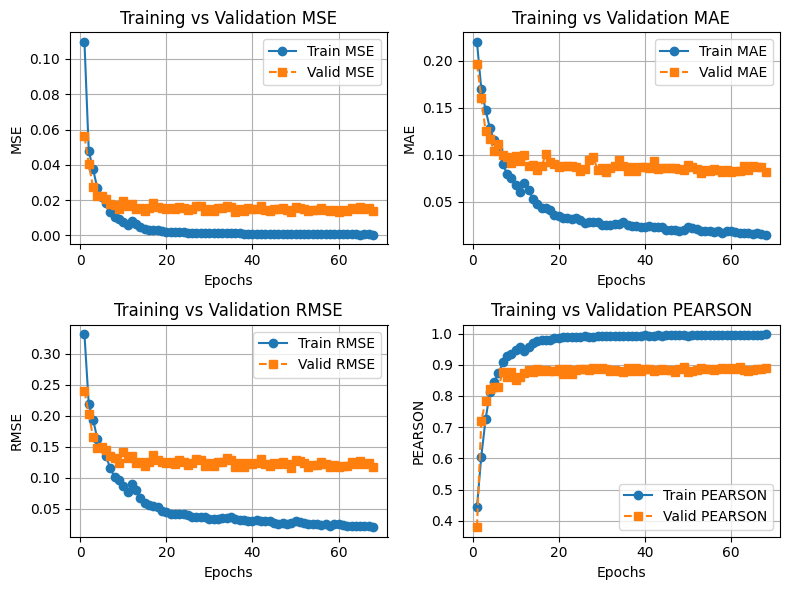

In [14]:
df_sindobert_22 = df_sindobert_epoch[df_sindobert_epoch['config_id']==22]
plot_training(df_sindobert_22)

## Sentence-IndoBERT

In [3]:
df_sindobert_after = pd.read_csv("../experiments/results/results_model_sindobert_after.csv")
print(df_sindobert_after.info())
df_sindobert_after.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      6 non-null      int64  
 1   model_name     6 non-null      object 
 2   batch_size     6 non-null      int64  
 3   epochs         6 non-null      int64  
 4   learning_rate  6 non-null      float64
 5   warm_up        6 non-null      float64
 6   dropout        6 non-null      float64
 7   training_time  6 non-null      float64
 8   peak_memory    6 non-null      float64
 9   test_mse       6 non-null      float64
 10  test_mae       6 non-null      float64
 11  test_rmse      6 non-null      float64
 12  test_pearson   6 non-null      float64
dtypes: float64(9), int64(3), object(1)
memory usage: 752.0+ bytes
None


,config_id,model_name,batch_size,epochs,learning_rate,warm_up,dropout,training_time,peak_memory,test_mse,test_mae,test_rmse,test_pearson
0,0,indobenchmark/indobert-lite-base-p2,4,82,0.00005,0.0,0.3,5666.027678,1767.721191,0.010457,0.076218,0.102685,0.920979
1,1,indobenchmark/indobert-lite-base-p2,16,32,0.00010,0.0,0.3,1961.320082,6564.331055,0.024426,0.120131,0.156562,0.799903
2,2,indobenchmark/indobert-lite-base-p2,4,21,0.00005,0.0,0.5,1494.701067,6564.331055,0.050099,0.170034,0.224679,0.489997
3,3,indobenchmark/indobert-lite-base-p2,16,35,0.00010,0.0,0.5,2009.845989,6566.881348,0.012989,0.089465,0.114289,0.897829
4,4,indobenchmark/indobert-lite-base-p2,4,54,0.00005,0.0,0.7,3517.671518,6566.881348,0.012133,0.078565,0.110594,0.903594


In [4]:
df_sindobert_epoch_after = pd.read_csv("../experiments/results/results_epoch_sindobert_after.csv")
print(df_sindobert_epoch_after.info())
df_sindobert_epoch_after.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 265 entries, 0 to 264
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      265 non-null    int64  
 1   epoch          265 non-null    int64  
 2   train_mse      265 non-null    float64
 3   train_mae      265 non-null    float64
 4   train_rmse     265 non-null    float64
 5   train_pearson  265 non-null    float64
 6   valid_mse      265 non-null    float64
 7   valid_mae      265 non-null    float64
 8   valid_rmse     265 non-null    float64
 9   valid_pearson  265 non-null    float64
 10  learning_rate  265 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 22.9 KB
None


,config_id,epoch,train_mse,train_mae,train_rmse,train_pearson,valid_mse,valid_mae,valid_rmse,valid_pearson,learning_rate
0,0,1,0.089681,0.225849,0.299377,0.477334,0.056414,0.190951,0.238711,0.372432,0.00005
1,0,2,0.064195,0.200276,0.253351,0.456633,0.053313,0.188491,0.231894,0.767809,0.00005
2,0,3,0.039420,0.156601,0.198562,0.718246,0.031521,0.134675,0.177188,0.827059,0.00005
3,0,4,0.028821,0.132510,0.169796,0.795759,0.022540,0.113617,0.150820,0.825956,0.00005
4,0,5,0.025385,0.124882,0.159295,0.819956,0.023247,0.114817,0.153230,0.806888,0.00005


### Top 5 Hyperparameter

In [6]:
print("\n============== Top 5 Configurations by MSE (Lower is Better) ==============")
top_mse = df_sindobert_after.nsmallest(5, 'test_mse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_mse']].copy()
print(top_mse.to_string(index=False))

print("\n============== Top 5 Configurations by MAE (Lower is Better) ==============")
top_mae = df_sindobert_after.nsmallest(5, 'test_mae')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_mae']].copy()
print(top_mae.to_string(index=False))

print("\n============== Top 5 Configurations by RMSE (Lower is Better) ==============")
top_rmse = df_sindobert_after.nsmallest(5, 'test_rmse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_rmse']].copy()
print(top_rmse.to_string(index=False))

print("\n============== Top 5 Configurations by Pearson Correlation (Higher is Better) ==============")
top_pearson = df_sindobert_after.nlargest(5, 'test_pearson')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'dropout', 'test_pearson']].copy()
print(top_pearson.to_string(index=False))


============== Top 5 Configurations by MSE (Lower is Better) ==============
 config_id                          model_name  batch_size  epochs  learning_rate  warm_up  dropout  test_mse
         0 indobenchmark/indobert-lite-base-p2           4      82        0.00005      0.0      0.3  0.010457
         5 indobenchmark/indobert-lite-base-p2          16      47        0.00010      0.0      0.7  0.011024
         4 indobenchmark/indobert-lite-base-p2           4      54        0.00005      0.0      0.7  0.012133
         3 indobenchmark/indobert-lite-base-p2          16      35        0.00010      0.0      0.5  0.012989
         1 indobenchmark/indobert-lite-base-p2          16      32        0.00010      0.0      0.3  0.024426

============== Top 5 Configurations by MAE (Lower is Better) ==============
 config_id                          model_name  batch_size  epochs  learning_rate  warm_up  dropout  test_mae
         0 indobenchmark/indobert-lite-base-p2           4      82        0.

## Analysis Best Hyperparameter

#### Config 0 Analysis

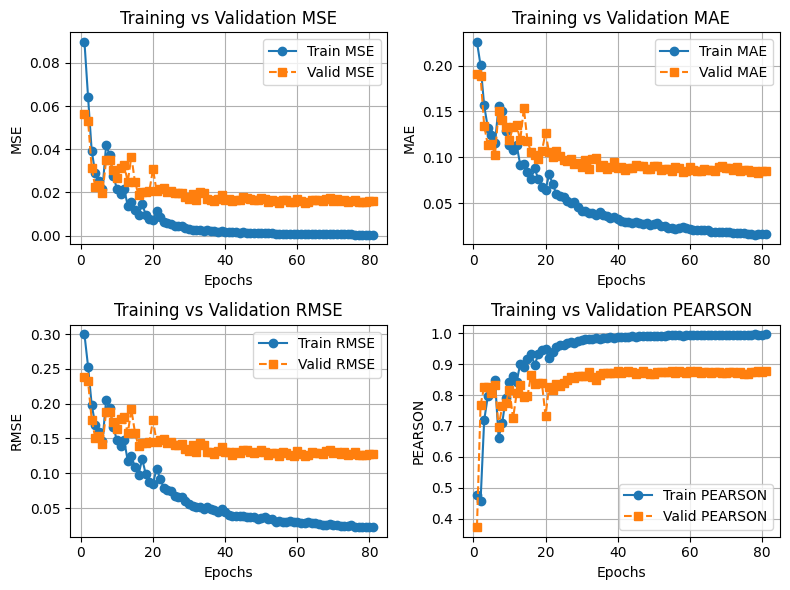

In [9]:
df_sindobert_after_0 = df_sindobert_epoch_after[df_sindobert_epoch_after['config_id']==0]
plot_training(df_sindobert_after_0)

#### Config 5 Analysis

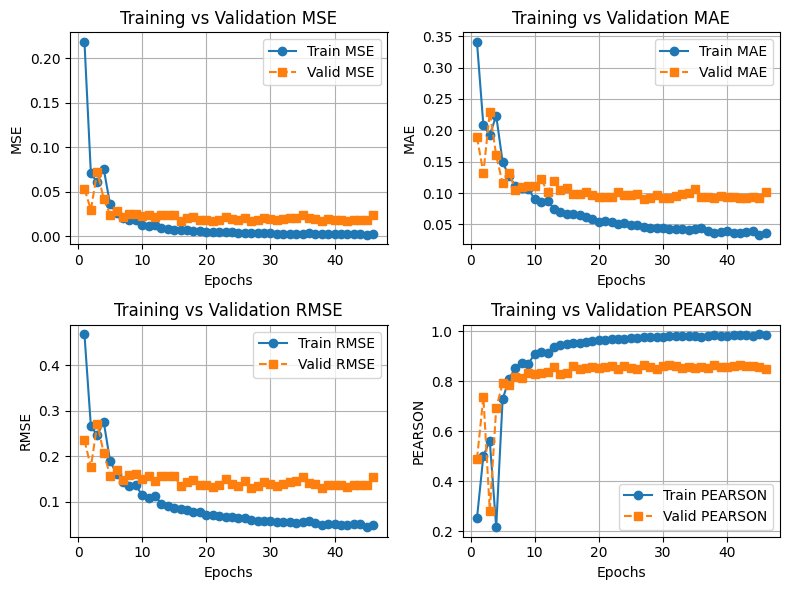

In [10]:
df_sindobert_after_5 = df_sindobert_epoch_after[df_sindobert_epoch_after['config_id']==5]
plot_training(df_sindobert_after_5)

## BERT-MULTI LEARNING RATE

In [52]:
df_bert_mlr = pd.read_csv("../experiments/results/results_model_bert_1.csv")        
print(df_bert_mlr.info())
df_bert_mlr.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48 entries, 0 to 47
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   config_id               48 non-null     int64  
 1   model_name              48 non-null     object 
 2   batch_size              48 non-null     int64  
 3   epochs                  48 non-null     int64  
 4   learning_rate_backbone  48 non-null     float64
 5   learning_rate_head      48 non-null     float64
 6   warm_up                 48 non-null     float64
 7   training_time           48 non-null     float64
 8   peak_memory             48 non-null     float64
 9   test_mse                48 non-null     float64
 10  test_mae                48 non-null     float64
 11  test_rmse               48 non-null     float64
 12  test_pearson            48 non-null     float64
 13  use_reference           48 non-null     bool   
dtypes: bool(1), float64(9), int64(3), object(1)


,config_id,model_name,batch_size,epochs,learning_rate_backbone,learning_rate_head,warm_up,training_time,peak_memory,test_mse,test_mae,test_rmse,test_pearson,use_reference
0,0,indobenchmark/indobert-lite-base-p2,4,12,0.00001,0.001,0.0,1477.175915,1335.881348,0.007221,0.065989,0.085289,0.944072,True
1,1,indobenchmark/indobert-lite-base-p2,4,12,0.00001,0.002,0.0,1460.563570,1335.982910,0.007127,0.066751,0.084728,0.945018,True
2,2,indobenchmark/indobert-lite-base-p2,4,28,0.00002,0.001,0.0,3387.399235,1337.084473,0.006834,0.061713,0.082815,0.946693,True
3,3,indobenchmark/indobert-lite-base-p2,4,18,0.00002,0.002,0.0,2135.146321,1337.834473,0.007172,0.064221,0.084958,0.944206,True
4,4,indobenchmark/indobert-lite-base-p2,8,12,0.00001,0.001,0.0,1296.733567,2532.506348,0.007872,0.067973,0.088858,0.939616,True


In [53]:
df_bert_epoch_mlr = pd.read_csv("../experiments/results/results_epoch_bert_1.csv")
print(df_bert_epoch_mlr.info())
df_bert_epoch_mlr.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1312 entries, 0 to 1311
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      1312 non-null   int64  
 1   epoch          1312 non-null   int64  
 2   train_mse      1312 non-null   float64
 3   train_mae      1312 non-null   float64
 4   train_rmse     1312 non-null   float64
 5   train_pearson  1312 non-null   float64
 6   valid_mse      1312 non-null   float64
 7   valid_mae      1312 non-null   float64
 8   valid_rmse     1312 non-null   float64
 9   valid_pearson  1312 non-null   float64
dtypes: float64(8), int64(2)
memory usage: 102.6 KB
None


,config_id,epoch,train_mse,train_mae,train_rmse,train_pearson,valid_mse,valid_mae,valid_rmse,valid_pearson
0,0,1,0.017114,0.096306,0.130850,0.876700,0.009986,0.078262,0.100212,0.926605
1,0,2,0.008013,0.068772,0.089502,0.944200,0.006561,0.062756,0.081541,0.949323
2,0,3,0.005926,0.058861,0.076997,0.958979,0.008857,0.074237,0.094526,0.943847
3,0,4,0.004059,0.049045,0.063708,0.972078,0.007369,0.065163,0.086447,0.942385
4,0,5,0.003308,0.043925,0.057515,0.977309,0.007185,0.065309,0.085342,0.942501


### Top 5 Hyperparameter

In [57]:
print("\n============== Top 5 Configurations by MSE (Lower is Better) ==============")
top_mse = df_bert_mlr.nsmallest(5, 'test_mse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate_backbone', 'learning_rate_head', 'warm_up', 'test_mse', 'use_reference']].copy()
print(top_mse.to_string(index=False))

print("\n============== Top 5 Configurations by MAE (Lower is Better) ==============")
top_mae = df_bert_mlr.nsmallest(5, 'test_mae')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate_backbone', 'learning_rate_head', 'warm_up', 'test_mae', 'use_reference']].copy()
print(top_mae.to_string(index=False))

print("\n============== Top 5 Configurations by RMSE (Lower is Better) ==============")
top_rmse = df_bert_mlr.nsmallest(5, 'test_rmse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate_backbone', 'learning_rate_head', 'warm_up', 'test_rmse', 'use_reference']].copy()
print(top_rmse.to_string(index=False))

print("\n============== Top 5 Configurations by Pearson Correlation (Higher is Better) ==============")
top_pearson = df_bert_mlr.nlargest(5, 'test_pearson')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate_backbone', 'learning_rate_head', 'warm_up', 'test_pearson', 'use_reference']].copy()
print(top_pearson.to_string(index=False))


============== Top 5 Configurations by MSE (Lower is Better) ==============
 config_id                          model_name  batch_size  epochs  learning_rate_backbone  learning_rate_head  warm_up  test_mse  use_reference
         6 indobenchmark/indobert-lite-base-p2           8      24                 0.00002               0.001      0.0  0.006403           True
        11 indobenchmark/indobert-lite-base-p2          16      27                 0.00002               0.002      0.0  0.006769           True
         2 indobenchmark/indobert-lite-base-p2           4      28                 0.00002               0.001      0.0  0.006834           True
         8 indobenchmark/indobert-lite-base-p2          16      16                 0.00001               0.001      0.0  0.006918           True
        18 indobenchmark/indobert-lite-base-p2           8      37                 0.00002               0.001      0.3  0.006936           True

============== Top 5 Configurations by MAE (Lower is

## Analysis Best Hyperparameter

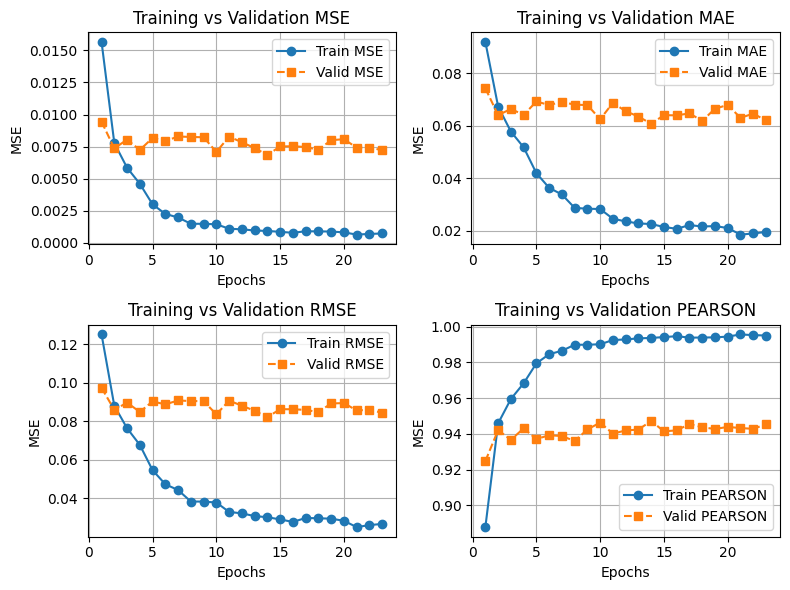

In [55]:
df_bert_mlr_6 = df_bert_epoch_mlr[df_bert_epoch_mlr['config_id']==6]
plot_training(df_bert_mlr_6)

## BERT WITH MULTI LR AND DIFFERENT DROPOUT

In [86]:
df_bert_mlr_after = pd.read_csv("../experiments/results/results_bert_mlr_after.csv")        
print(df_bert_mlr_after.info())
df_bert_mlr_after.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   config_id               4 non-null      int64  
 1   model_name              4 non-null      object 
 2   batch_size              4 non-null      int64  
 3   epochs                  4 non-null      int64  
 4   learning_rate_backbone  4 non-null      float64
 5   learning_rate_head      4 non-null      float64
 6   warm_up                 4 non-null      float64
 7   dropout                 4 non-null      float64
 8   training_time           4 non-null      float64
 9   peak_memory             4 non-null      float64
 10  test_mse                4 non-null      float64
 11  test_mae                4 non-null      float64
 12  test_rmse               4 non-null      float64
 13  test_pearson            4 non-null      float64
 14  use_reference           4 non-null      bool  

,config_id,model_name,batch_size,epochs,learning_rate_backbone,learning_rate_head,warm_up,dropout,training_time,peak_memory,test_mse,test_mae,test_rmse,test_pearson,use_reference
0,0,indobenchmark/indobert-lite-base-p2,8,36,0.00002,0.001,0.0,0.3,3932.619598,2532.029785,0.006991,0.061549,0.083614,0.945930,True
1,1,indobenchmark/indobert-lite-base-p2,8,18,0.00002,0.001,0.0,0.5,1992.502598,2533.131348,0.007629,0.067146,0.087451,0.942805,True
2,2,indobenchmark/indobert-lite-base-p2,16,45,0.00002,0.002,0.0,0.3,4635.976342,4898.123535,0.006744,0.061627,0.082298,0.948844,True
3,3,indobenchmark/indobert-lite-base-p2,16,21,0.00002,0.002,0.0,0.5,2235.006387,4898.123535,0.007372,0.065599,0.086010,0.943497,True


In [87]:
df_bert_epoch_mlr_after = pd.read_csv("../experiments/results/results_epoch_bert_mlr_after.csv")
print(df_bert_epoch_mlr_after.info())
df_bert_epoch_mlr_after.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116 entries, 0 to 115
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      116 non-null    int64  
 1   epoch          116 non-null    int64  
 2   train_mse      116 non-null    float64
 3   train_mae      116 non-null    float64
 4   train_rmse     116 non-null    float64
 5   train_pearson  116 non-null    float64
 6   valid_mse      116 non-null    float64
 7   valid_mae      116 non-null    float64
 8   valid_rmse     116 non-null    float64
 9   valid_pearson  116 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 9.2 KB
None


,config_id,epoch,train_mse,train_mae,train_rmse,train_pearson,valid_mse,valid_mae,valid_rmse,valid_pearson
0,0,1,0.052574,0.167306,0.229338,0.684290,0.017411,0.105911,0.131811,0.901767
1,0,2,0.018570,0.107847,0.136287,0.874184,0.010498,0.078499,0.102571,0.925497
2,0,3,0.012893,0.089618,0.113564,0.910519,0.009574,0.077004,0.097922,0.935054
3,0,4,0.009414,0.077336,0.097034,0.934821,0.008292,0.070282,0.091133,0.938959
4,0,5,0.007908,0.069718,0.088945,0.945333,0.008254,0.070593,0.090971,0.934500


### Top Hyperparameter

In [88]:
print("\n============== Top 4 Configurations by MSE (Lower is Better) ==============")
top_mse = df_bert_mlr_after.nsmallest(4, 'test_mse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate_backbone', 'learning_rate_head', 'warm_up', 'test_mse', 'use_reference']].copy()
print(top_mse.to_string(index=False))

print("\n============== Top 4 Configurations by MAE (Lower is Better) ==============")
top_mae = df_bert_mlr_after.nsmallest(4, 'test_mae')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate_backbone', 'learning_rate_head', 'warm_up', 'test_mae', 'use_reference']].copy()
print(top_mae.to_string(index=False))

print("\n============== Top 4 Configurations by RMSE (Lower is Better) ==============")
top_rmse = df_bert_mlr_after.nsmallest(4, 'test_rmse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate_backbone', 'learning_rate_head', 'warm_up', 'test_rmse', 'use_reference']].copy()
print(top_rmse.to_string(index=False))

print("\n============== Top 4 Configurations by Pearson Correlation (Higher is Better) ==============")
top_pearson = df_bert_mlr_after.nlargest(4, 'test_pearson')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate_backbone', 'learning_rate_head', 'warm_up', 'test_pearson', 'use_reference']].copy()
print(top_pearson.to_string(index=False))


============== Top 4 Configurations by MSE (Lower is Better) ==============
 config_id                          model_name  batch_size  epochs  learning_rate_backbone  learning_rate_head  warm_up  test_mse  use_reference
         2 indobenchmark/indobert-lite-base-p2          16      45                 0.00002               0.002      0.0  0.006744           True
         0 indobenchmark/indobert-lite-base-p2           8      36                 0.00002               0.001      0.0  0.006991           True
         3 indobenchmark/indobert-lite-base-p2          16      21                 0.00002               0.002      0.0  0.007372           True
         1 indobenchmark/indobert-lite-base-p2           8      18                 0.00002               0.001      0.0  0.007629           True

============== Top 4 Configurations by MAE (Lower is Better) ==============
 config_id                          model_name  batch_size  epochs  learning_rate_backbone  learning_rate_head  warm_up  

## Analysis Best Hyperparameter

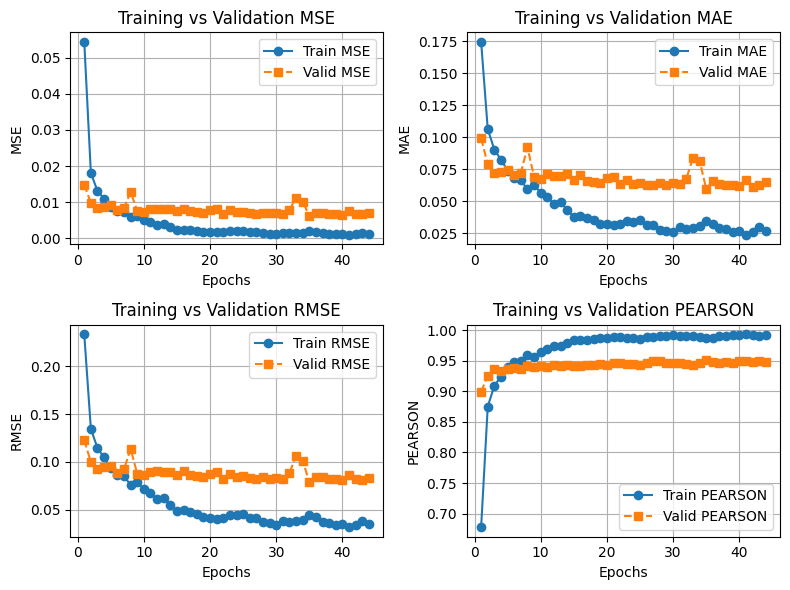

In [89]:
df_bert_mlr_after_2 = df_bert_epoch_mlr_after[df_bert_epoch_mlr_after['config_id']==2]
plot_training(df_bert_mlr_after_2)

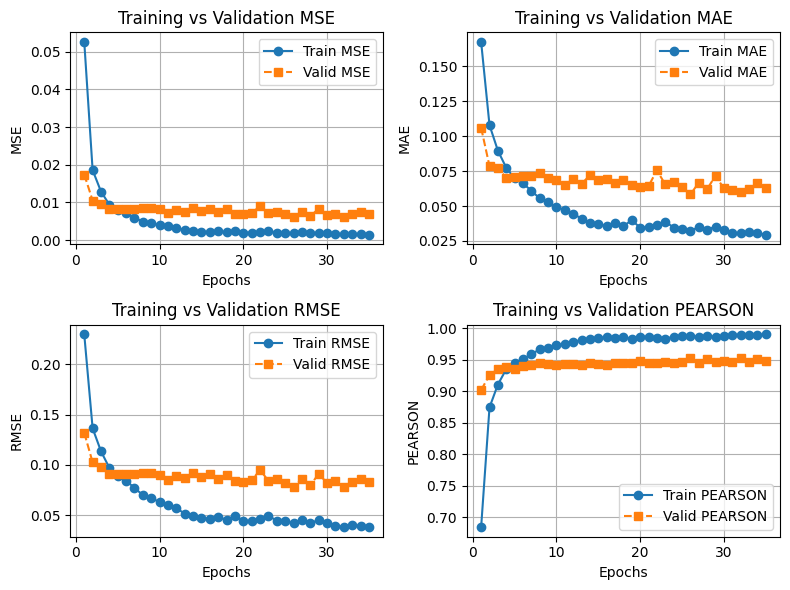

In [90]:
df_bert_mlr_after_0 = df_bert_epoch_mlr_after[df_bert_epoch_mlr_after['config_id']==0]
plot_training(df_bert_mlr_after_0)

## Siamese Similarity Learning (Cosine Similarity)

In [4]:
df_sim = pd.read_csv("../experiments/results/results_model_siamese.csv")        
print(df_sim.info())
df_sim.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      25 non-null     int64  
 1   model_name     25 non-null     object 
 2   batch_size     25 non-null     int64  
 3   epochs         25 non-null     int64  
 4   learning_rate  25 non-null     float64
 5   warm_up        25 non-null     float64
 6   training_time  25 non-null     float64
 7   peak_memory    25 non-null     float64
 8   test_mse       25 non-null     float64
 9   test_mae       25 non-null     float64
 10  test_rmse      25 non-null     float64
 11  test_pearson   25 non-null     float64
dtypes: float64(8), int64(3), object(1)
memory usage: 2.5+ KB
None


,config_id,model_name,batch_size,epochs,learning_rate,warm_up,training_time,peak_memory,test_mse,test_mae,test_rmse,test_pearson
0,0,sentence-transformers/paraphrase-multilingual-...,4,18,0.00001,0.0,1986.336651,6419.152344,0.010225,0.075173,0.101197,0.922639
1,1,sentence-transformers/paraphrase-multilingual-...,4,30,0.00001,0.3,3298.367699,6420.800781,0.011138,0.080181,0.105676,0.916192
2,2,sentence-transformers/paraphrase-multilingual-...,4,17,0.00002,0.0,1815.616656,6420.800781,0.010196,0.074721,0.101389,0.923242
3,3,sentence-transformers/paraphrase-multilingual-...,4,21,0.00002,0.3,2242.455163,6420.800781,0.012624,0.087218,0.112705,0.905938
4,4,sentence-transformers/paraphrase-multilingual-...,8,14,0.00001,0.0,1102.990872,6616.846191,0.010714,0.078990,0.103752,0.921219


In [5]:
df_sim_epoch = pd.read_csv("../experiments/results/results_epoch_siamese.csv")
print(df_sim_epoch.info())
df_sim_epoch.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   config_id      521 non-null    int64  
 1   epoch          521 non-null    int64  
 2   train_mse      521 non-null    float64
 3   train_mae      521 non-null    float64
 4   train_rmse     521 non-null    float64
 5   train_pearson  521 non-null    float64
 6   valid_mse      521 non-null    float64
 7   valid_mae      521 non-null    float64
 8   valid_rmse     521 non-null    float64
 9   valid_pearson  521 non-null    float64
 10  learning_rate  521 non-null    float64
dtypes: float64(9), int64(2)
memory usage: 44.9 KB
None


,config_id,epoch,train_mse,train_mae,train_rmse,train_pearson,valid_mse,valid_mae,valid_rmse,valid_pearson,learning_rate
0,0,1,0.020943,0.108779,0.144747,0.860575,0.012182,0.082628,0.110740,0.913302,0.00001
1,0,2,0.008558,0.071117,0.092519,0.941566,0.012773,0.086822,0.113663,0.908341,0.00001
2,0,3,0.005673,0.057656,0.075319,0.961370,0.012192,0.083675,0.108725,0.912521,0.00001
3,0,4,0.004217,0.049572,0.064950,0.971214,0.010304,0.074979,0.102216,0.922414,0.00001
4,0,5,0.003409,0.044561,0.058373,0.976879,0.012309,0.080154,0.111260,0.909397,0.00001


### Top 5 Hyperparameter

In [7]:
print("\n============== Top 5 Configurations by MSE (Lower is Better) ==============")
top_mse = df_sim.nsmallest(5, 'test_mse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_mse']].copy()
print(top_mse.to_string(index=False))

print("\n============== Top 5 Configurations by MAE (Lower is Better) ==============")
top_mae = df_sim.nsmallest(5, 'test_mae')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_mae']].copy()
print(top_mae.to_string(index=False))

print("\n============== Top 5 Configurations by RMSE (Lower is Better) ==============")
top_rmse = df_sim.nsmallest(5, 'test_rmse')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_rmse']].copy()
print(top_rmse.to_string(index=False))

print("\n============== Top 5 Configurations by Pearson Correlation (Higher is Better) ==============")
top_pearson = df_sim.nlargest(5, 'test_pearson')[['config_id', 'model_name', 'batch_size', 'epochs', 'learning_rate', 'warm_up', 'test_pearson']].copy()
print(top_pearson.to_string(index=False))


============== Top 5 Configurations by MSE (Lower is Better) ==============
 config_id                                                  model_name  batch_size  epochs  learning_rate  warm_up  test_mse
        12 sentence-transformers/paraphrase-multilingual-mpnet-base-v2           4      31        0.00005      0.0  0.009848
        10 sentence-transformers/paraphrase-multilingual-mpnet-base-v2          16      42        0.00002      0.0  0.009993
         2 sentence-transformers/paraphrase-multilingual-mpnet-base-v2           4      17        0.00002      0.0  0.010196
        20 sentence-transformers/paraphrase-multilingual-mpnet-base-v2          16      24        0.00005      0.0  0.010198
         0 sentence-transformers/paraphrase-multilingual-mpnet-base-v2           4      18        0.00001      0.0  0.010225

============== Top 5 Configurations by MAE (Lower is Better) ==============
 config_id                                                  model_name  batch_size  epochs  lear

## Analysis Best Hyperparameter

#### Config 12 Analysis

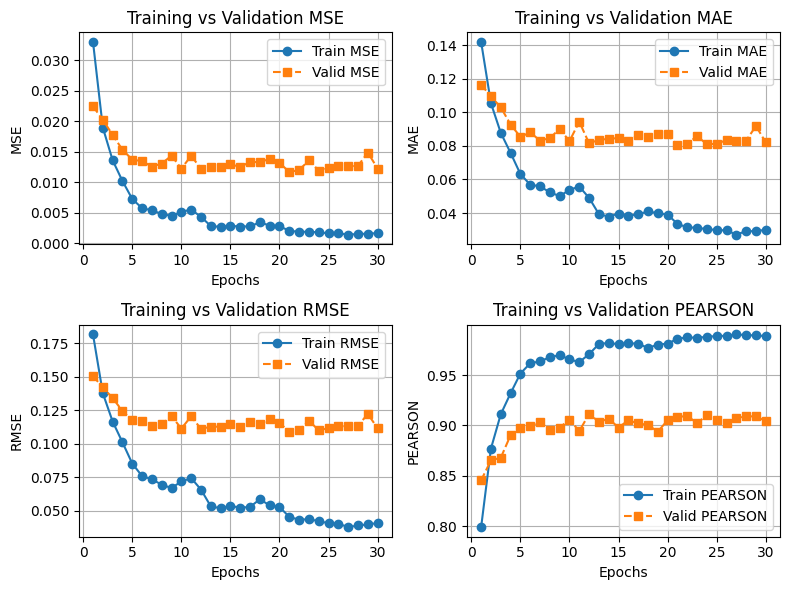

In [8]:
df_sim_12 = df_sim_epoch[df_sim_epoch['config_id']==12]
plot_training(df_sim_12)

#### Config 10 Analysis

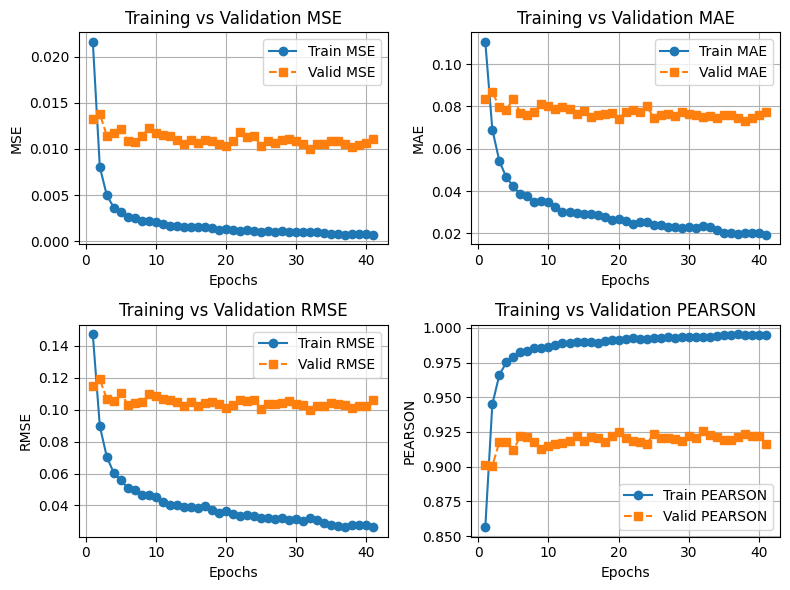

In [9]:
df_sim_10 = df_sim_epoch[df_sim_epoch['config_id']==10]
plot_training(df_sim_10)